<a href="https://colab.research.google.com/github/Ritik4259/Diabetes-Prediction/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report,accuracy_score,roc_curve,roc_auc_score,confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ML Projects/Classification/diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df.shape

(100000, 9)

In [ ]:
df[(df['smoking_history']=='No Info')].shape[0]

35816

In [ ]:
mapping = {
    'never': 'never',
    'former': 'former',
    'current': 'current',
    'ever': 'former',
    'not current': 'former',
    'No Info': 'unknown'
}

df['smoking_history'] = df['smoking_history'].map(mapping)


In [ ]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,unknown,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df = pd.get_dummies(
    df,
    columns=['smoking_history','gender'],
)


In [ ]:
df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_former,smoking_history_never,smoking_history_unknown,gender_Female,gender_Male,gender_Other
0,80.0,0,1,25.19,6.6,140,0,False,False,True,False,True,False,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,True,True,False,False
2,28.0,0,0,27.32,5.7,158,0,False,False,True,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,True,False,False,False,True,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,False,False,False,True,False


In [ ]:
df[['smoking_history_current','smoking_history_former','smoking_history_never','smoking_history_unknown','gender_Male','gender_Other']] = df[['smoking_history_current','smoking_history_former','smoking_history_never','smoking_history_unknown','gender_Male','gender_Other']].astype(int)

In [ ]:
df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_former,smoking_history_never,smoking_history_unknown,gender_Female,gender_Male,gender_Other
0,80.0,0,1,25.19,6.6,140,0,0,0,1,0,True,0,0
1,54.0,0,0,27.32,6.6,80,0,0,0,0,1,True,0,0
2,28.0,0,0,27.32,5.7,158,0,0,0,1,0,False,1,0
3,36.0,0,0,23.45,5.0,155,0,1,0,0,0,True,0,0
4,76.0,1,1,20.14,4.8,155,0,1,0,0,0,False,1,0


In [ ]:
df['smoking_check'] = (
    df[['smoking_history_former',
        'smoking_history_current',
        'smoking_history_unknown']].sum(axis=1)
)

df['smoking_check'].value_counts()


,count
smoking_check,
1,64905
0,35095


In [ ]:
df = df.drop('smoking_history_never',axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      100000 non-null  float64
 1   hypertension             100000 non-null  int64  
 2   heart_disease            100000 non-null  int64  
 3   bmi                      100000 non-null  float64
 4   HbA1c_level              100000 non-null  float64
 5   blood_glucose_level      100000 non-null  int64  
 6   diabetes                 100000 non-null  int64  
 7   smoking_history_current  100000 non-null  int64  
 8   smoking_history_former   100000 non-null  int64  
 9   smoking_history_unknown  100000 non-null  int64  
 10  gender_Female            100000 non-null  bool   
 11  gender_Male              100000 non-null  int64  
 12  gender_Other             100000 non-null  int64  
 13  smoking_check            100000 non-null  int64  
dtypes: bo

In [ ]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_former,smoking_history_unknown,gender_Male,gender_Other,smoking_check
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000,0.092860,0.198030,0.358160,0.414300,0.000180,0.64905
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883,0.290238,0.398517,0.479462,0.492603,0.013415,0.47727
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.00000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
X = df.drop(columns=['diabetes'])
X.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,smoking_history_current,smoking_history_former,smoking_history_unknown,gender_Female,gender_Male,gender_Other,smoking_check
0,80.0,0,1,25.19,6.6,140,0,0,0,True,0,0,0
1,54.0,0,0,27.32,6.6,80,0,0,1,True,0,0,1
2,28.0,0,0,27.32,5.7,158,0,0,0,False,1,0,0
3,36.0,0,0,23.45,5.0,155,1,0,0,True,0,0,1
4,76.0,1,1,20.14,4.8,155,1,0,0,False,1,0,1


In [ ]:
y = df['diabetes']
y.head()

,diabetes
0,0
1,0
2,0
3,0
4,0


# Visualization

## Count plot

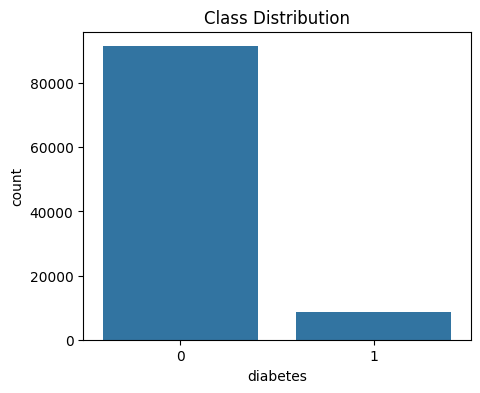

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='diabetes',data=df)
#sns.counterplot(x=y)
plt.title("Class Distribution")
plt.show()

Since we have extreme class imbalance accuarcy will be misleading, since any model always predicting 0 will also have 90 accuracy, so we will focus on recal (how many of predicted positives were actually positive)

In [ ]:
df.nunique()

,0
age,102
hypertension,2
heart_disease,2
bmi,4247
HbA1c_level,18
blood_glucose_level,18
diabetes,2
smoking_history_current,2
smoking_history_former,2
smoking_history_unknown,2


In [ ]:
num_col = ['age','bmi','HbA1c_level','blood_glucose_level']

cat_col = [col for col in X.columns if col not in num_col]

cat_col

['hypertension',
 'heart_disease',
 'smoking_history_current',
 'smoking_history_former',
 'smoking_history_unknown',
 'gender_Female',
 'gender_Male',
 'gender_Other',
 'smoking_check']

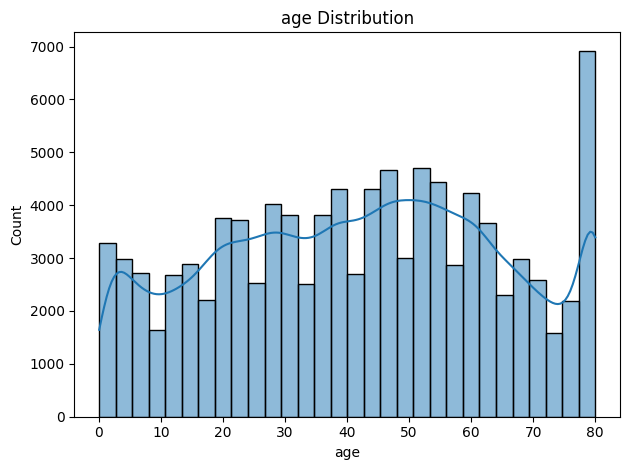

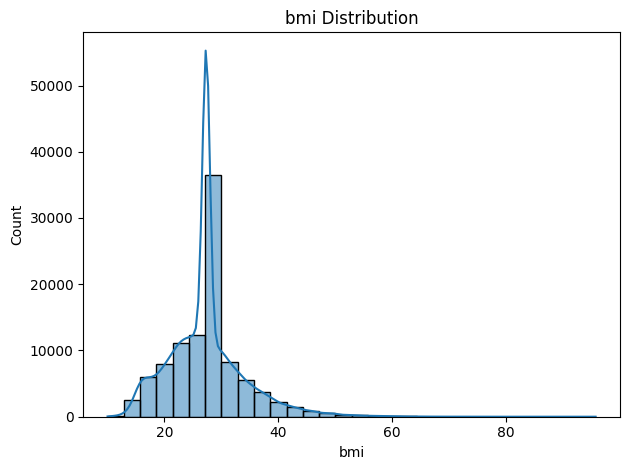

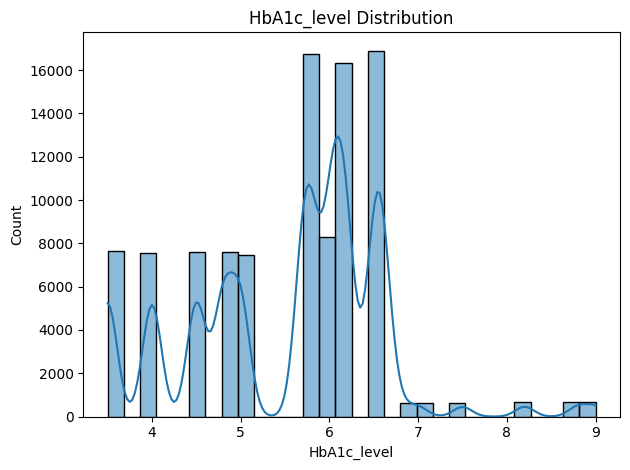

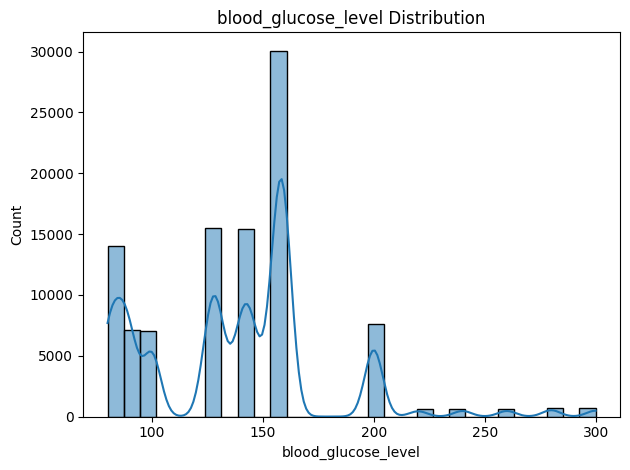

In [ ]:
for col in num_col:
    sns.histplot(X[col], bins=30, kde=True)
    plt.title(f"{col} Distribution")
    plt.tight_layout()
    plt.show()


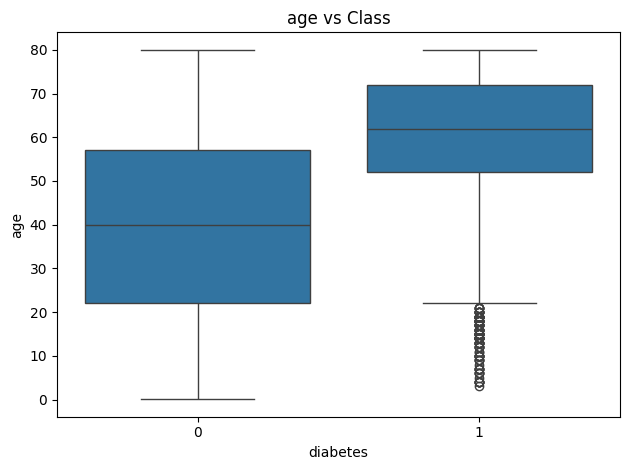

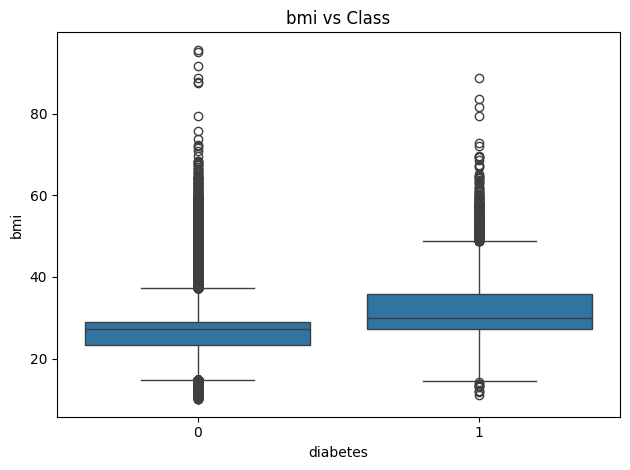

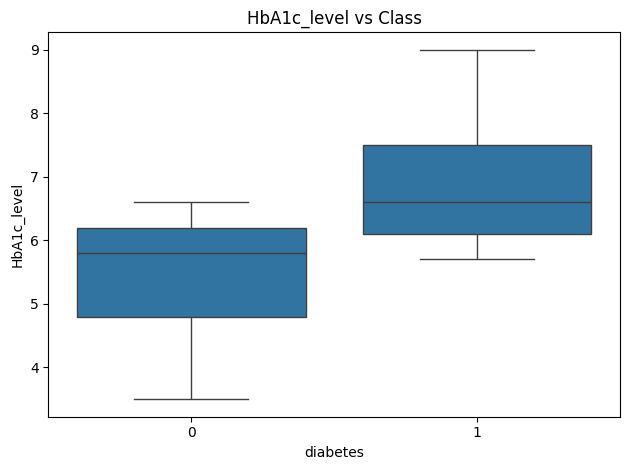

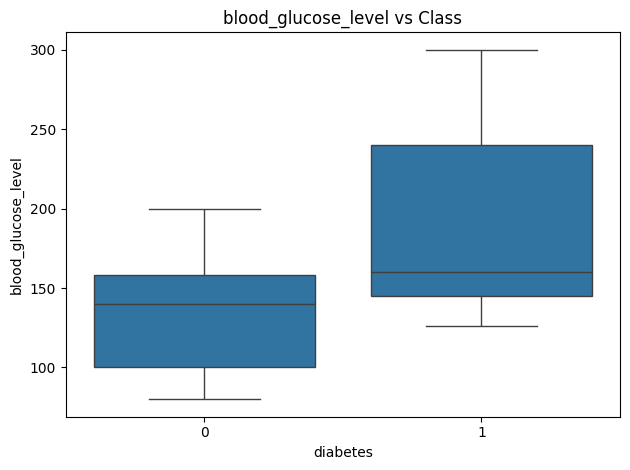

In [ ]:
for col in num_col:
    sns.boxplot(x=y, y=X[col])
    plt.title(f"{col} vs Class")
    plt.tight_layout()
    plt.show()


In [ ]:
df = df[(df["bmi"] >= 12) & (df["bmi"] <= 70)].reset_index(drop=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99898 entries, 0 to 99897
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      99898 non-null  float64
 1   hypertension             99898 non-null  int64  
 2   heart_disease            99898 non-null  int64  
 3   bmi                      99898 non-null  float64
 4   HbA1c_level              99898 non-null  float64
 5   blood_glucose_level      99898 non-null  int64  
 6   diabetes                 99898 non-null  int64  
 7   smoking_history_current  99898 non-null  int64  
 8   smoking_history_former   99898 non-null  int64  
 9   smoking_history_unknown  99898 non-null  int64  
 10  gender_Female            99898 non-null  bool   
 11  gender_Male              99898 non-null  int64  
 12  gender_Other             99898 non-null  int64  
 13  smoking_check            99898 non-null  int64  
dtypes: bool(1), float64(3)

In [ ]:
X = df.drop(columns=["diabetes"])
X.sample(5)

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,smoking_history_current,smoking_history_former,smoking_history_unknown,gender_Female,gender_Male,gender_Other,smoking_check
19093,41.0,0,0,37.76,5.8,159,0,0,0,True,0,0,0
34987,30.0,0,0,21.69,5.8,130,0,0,0,True,0,0,0
1021,20.0,0,0,22.04,6.5,126,0,1,0,False,1,0,1
87063,56.0,0,1,44.00,6.6,80,0,0,1,True,0,0,1
72193,42.0,0,0,27.32,4.0,130,0,0,0,False,1,0,0


In [ ]:
y = df['diabetes']
y.head()

,diabetes
0,0
1,0
2,0
3,0
4,0


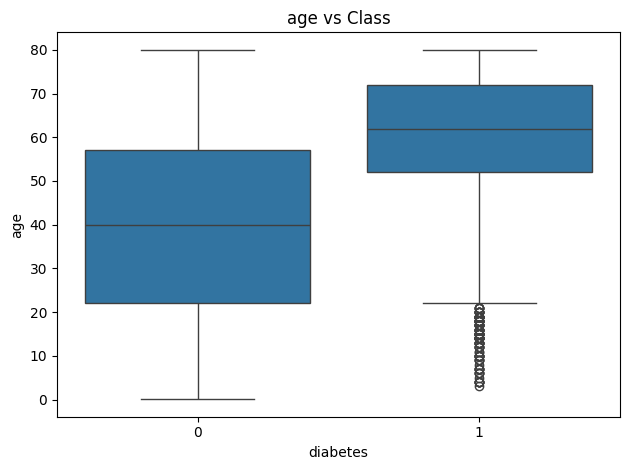

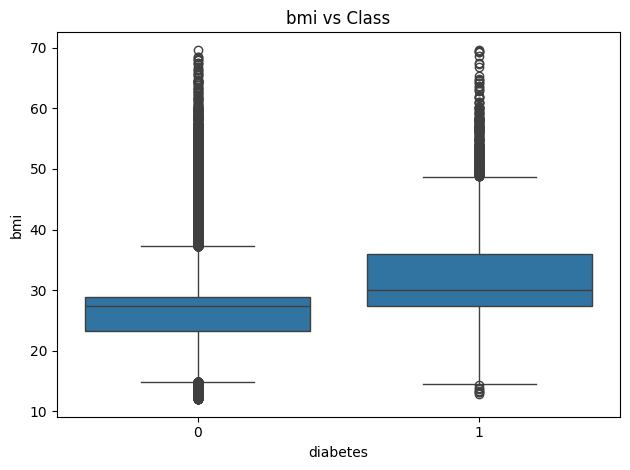

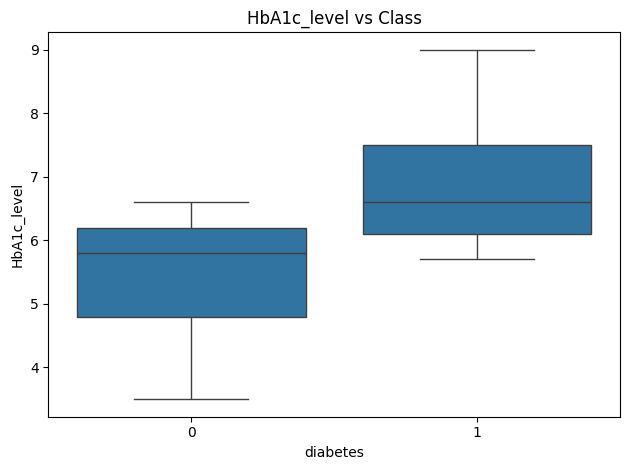

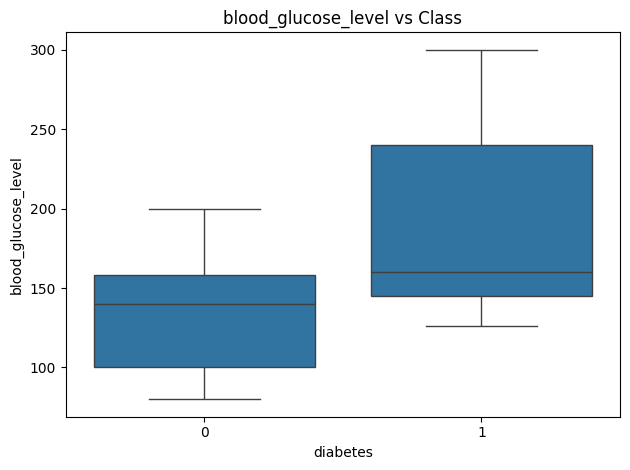

In [ ]:
for col in num_col:
    sns.boxplot(x=y, y=X[col])
    plt.title(f"{col} vs Class")
    plt.tight_layout()
    plt.show()


## Heatmap (to check correlation)

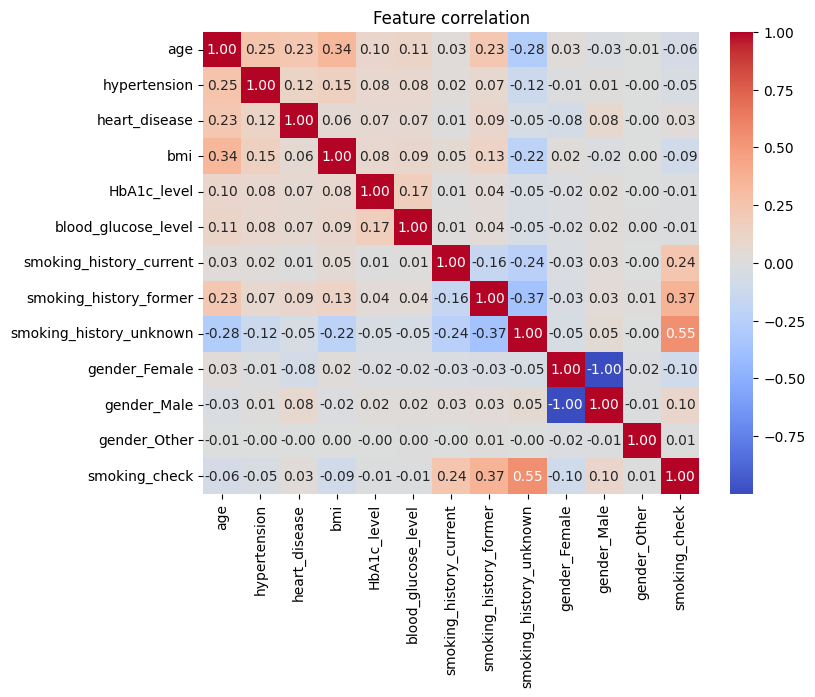

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Feature correlation")
plt.show()

# Splitting

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y)

# Scaling

In [ ]:
scaler = RobustScaler()

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

x_train_scaled[num_col] = scaler.fit_transform(x_train[num_col])
x_test_scaled[num_col] = scaler.transform(x_test[num_col])

# Training

In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=0.5,                    # ↓ reduces overfitting & false positives
    gamma=0.01,               # ↓ smoother decision boundary
    class_weight="balanced",  # mandatory for imbalance
    probability=True,         # enables probability output
    random_state=42
)

svm.fit(x_train_scaled,y_train)
svm_pred = svm.predict(x_test_scaled)

In [ ]:
print(classification_report(y_test,svm_pred))

              precision    recall  f1-score   support

           0       0.99      0.89      0.93     27423
           1       0.42      0.88      0.57      2547

    accuracy                           0.89     29970
   macro avg       0.70      0.88      0.75     29970
weighted avg       0.94      0.89      0.90     29970



In [ ]:
confusion_matrix(y_test,svm_pred)

array([[24321,  3102],
       [  306,  2241]])

In [ ]:
svc = SVC(
    probability=True,       # allows later threshold tuning
    random_state=42
)


In [ ]:
param_grid = {
    'C': [0.1, 1, 5, 10],
    'gamma': [0.001, 0.01, 0.1, 'scale'],
    'kernel': ['rbf'],
    'class_weight': ['balanced'],
}

In [ ]:
grid = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='recall',      # IMPORTANT for diabetes
    cv=3,                  # lower CV for faster run
    n_jobs=2               # avoid memory overload
)

In [ ]:
grid.fit(x_train_scaled, y_train)

KeyboardInterrupt: 

In [ ]:
best_svc = grid.best_estimator_
print("Best params:", grid.best_params_)

## Logistic Regression

In [ ]:
logistic = LogisticRegression(
    solver="liblinear",   # supports L1 & L2
    max_iter=1000
    )
logistic.fit(x_train_scaled,y_train)
log_pred = logistic.predict(x_test_scaled)

In [ ]:
print(classification_report(y_test,log_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     27423
           1       0.86      0.62      0.72      2547

    accuracy                           0.96     29970
   macro avg       0.91      0.81      0.85     29970
weighted avg       0.96      0.96      0.96     29970



### Hyperparamter tuning

In [ ]:
param_grid = {
    "C": [0.01, 0.1, 1, 5, 10],
    "penalty": ["l1", "l2"],
    "class_weight": ["balanced"],
}


In [ ]:
grid = GridSearchCV(
    estimator=logistic,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(x_train_scaled, y_train)


GridSearchCV(cv=5,
             estimator=LogisticRegression(max_iter=1000, solver='liblinear'),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 5, 10],
                         'class_weight': ['balanced'],
                         'penalty': ['l1', 'l2']},
             scoring='f1')

In [ ]:
best_lr = grid.best_estimator_

print("Best parameters:", grid.best_params_)


In [ ]:
y_pred = best_lr.predict(x_test_scaled)

print(classification_report(y_test, y_pred))


In [ ]:
grid = GridSearchCV(
    estimator=logistic,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

grid.fit(x_train_scaled, y_train)


In [ ]:
best_lr = grid.best_estimator_

print("Best parameters:", grid.best_params_)


In [ ]:
y_pred = best_lr.predict(x_test_scaled)

print(classification_report(y_test, y_pred))


In [ ]:
y_prob = best_lr.predict_proba(x_test_scaled)[:, 1]

y_pred_custom = (y_prob >= 0.68).astype(int)

print(classification_report(y_test, y_pred_custom))


In [ ]:
tree = DecisionTreeClassifier()
tree.fit(x_train_scaled,y_train)
tree_pred = tree.predict(x_test_scaled)

In [ ]:
print(classification_report(y_test,tree_pred))

In [ ]:
param_grid = {
    "class_weight": ["balanced"],
    "criterion": ['entropy','gini'],
    "splitter" : ["best"],
    "max_depth": [3, 4, 5, 6],
    "min_samples_split": [20, 30, 50],
    "min_samples_leaf": [5, 10, 15],
}


In [ ]:
grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
    verbose = 3
)

grid.fit(x_train_scaled, y_train)

In [ ]:
best_tree = grid.best_estimator_
print("Best Params:", grid.best_params_)

In [ ]:
y_pred = best_tree.predict(x_test_scaled)

print(classification_report(y_test, y_pred))

In [ ]:
confusion_matrix(y_test,y_pred)

In [ ]:
rf = RandomForestClassifier(
    class_weight={0:1, 1:2},
    random_state=42
)

rf.fit(x_train_scaled,y_train)
rf_pred = forest.predict(x_test_scaled)

In [ ]:
print(classification_report(y_test,rf_pred))

In [ ]:
confusion_matrix(y_test,rf_pred)

In [ ]:
y_prob = rf.predict_proba(x_test_scaled)[:,1]

y_pred = (y_prob >= 0.38).astype(int)


In [ ]:
print(classification_report(y_test,y_pred))

In [ ]:
param_dist = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 4, 8, 16],
    'max_features': ['auto', 'sqrt', 0.3, 0.5],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'bootstrap': [True, False],
    'class_weight': ['balanced']
}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

rand = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,                      # tries 30 random combos
    scoring='recall_weighted',               # because diabetes: recall-critical
    cv=3,                           # fewer folds = faster
    random_state=42,
    n_jobs=2                        # avoid worker crashes
)


In [ ]:
rand.fit(x_train_scaled, y_train)


In [ ]:
best_rf = rand.best_estimator_
print("Best params:", rand.best_params_)


In [ ]:
y_pred = best_rf.predict(x_test_scaled)
print(classification_report(y_test, y_pred))


In [ ]:
y_prob = best_rf.predict_proba(x_test_scaled)[:,1]
y_pred = (y_prob >= 0.38).astype(int)


In [ ]:
print(classification_report(y_test, y_pred))


In [ ]:
confusion_matrix(y_test,y_pred)

# Task
Generate a comprehensive report on the diabetes prediction analysis, including: the main objective of the analysis; a detailed description of the dataset, its features, distributions, and preprocessing steps; a comparison of the performance of different classification models (SVC, Logistic Regression, Decision Tree, Random Forest) using appropriate metrics like precision, recall, F1-score, and confusion matrices, with a focus on maximizing recall; a summary of key findings and insights from the data exploration and model evaluations; a discussion of model limitations and proposed next steps for future work; and a concluding summary of the entire analysis and its implications.

## Add Main Objective

### Subtask:
Insert a paragraph at the beginning of the report detailing the main objective of this diabetes prediction analysis.


## Main Objective

This analysis aims to build and evaluate classification models for predicting diabetes. Given the critical nature of early diagnosis and the potentially imbalanced distribution of diabetic versus non-diabetic cases, a primary focus will be placed on optimizing model recall. High recall ensures that a maximum number of actual diabetic cases are correctly identified, minimizing false negatives and allowing for timely intervention. We will explore various machine learning algorithms, including Support Vector Machines, Logistic Regression, Decision Trees, and Random Forests, and meticulously tune their hyperparameters to achieve robust predictive performance, particularly concerning the identification of positive cases.

## Describe Data Features

### Subtask:
Create a section describing the dataset, its features (numerical and categorical), their distributions, and how they are prepared for modeling. This will include insights from `df.head()`, `df.info()`, `df.describe()`, `nunique()`, `num_col`, `cat_col`, and the various visualization plots.


## Describe Data Features

This section provides a detailed overview of the dataset, its features, their distributions, and the preprocessing steps undertaken to prepare the data for machine learning models.

### Initial Dataset Structure
The dataset initially contained `100,000` rows and `9` columns, as shown by `df.shape`. The `df.head()` output revealed a mix of numerical and categorical features:

| Feature             | Type      | Example Values      |
| :------------------ | :-------- | :------------------ |
| `gender`            | Categorical | Female, Male, Other |
| `age`               | Numerical | 80.0, 54.0, 28.0    |
| `hypertension`      | Numerical | 0, 1                |
| `heart_disease`     | Numerical | 0, 1                |
| `smoking_history`   | Categorical | never, No Info, current |
| `bmi`               | Numerical | 25.19, 27.32, 23.45 |
| `HbA1c_level`       | Numerical | 6.6, 5.7, 5.0       |
| `blood_glucose_level` | Numerical | 140, 80, 158        |
| `diabetes`          | Numerical | 0, 1                |

`df.info()` confirmed data types, showing `age`, `bmi`, `HbA1c_level` as `float64`, and others as `int64` or `object` (for `gender` and `smoking_history`). No missing values were identified across any columns.

`df.describe()` provided statistical summaries:
- `age`: Ranges from 0.08 to 80.0, with a mean of ~41.89. The distribution is wide, covering infants to elderly.
- `bmi`: Ranges from 10.01 to 95.69, with a mean of ~27.32. This column showed a relatively wide range.
- `HbA1c_level`: Ranges from 3.5 to 9.0, with a mean of ~5.53.
- `blood_glucose_level`: Ranges from 80 to 300, with a mean of ~138.06.
- `hypertension`, `heart_disease`, `diabetes`, `smoking_history_current`, `smoking_history_former`, `smoking_history_unknown`, `gender_Male`, `gender_Other`, `smoking_check` are binary or count-based, with means reflecting the proportion of '1's.

### Feature Identification
Based on their nature and the analyses, features were categorized as follows:
- **Numerical Columns (`num_col`):** `age`, `bmi`, `HbA1c_level`, `blood_glucose_level`.
- **Categorical Columns (`cat_col`):** `hypertension`, `heart_disease`, `smoking_history_current`, `smoking_history_former`, `smoking_history_unknown`, `gender_Female`, `gender_Male`, `gender_Other`, `smoking_check`.

The `df.nunique()` output showed that `gender` had 3 unique values ('Female', 'Male', 'Other') and `smoking_history` had 6 unique values ('never', 'No Info', 'current', 'ever', 'not current', 'former'), highlighting the need for encoding.

### Data Preprocessing Steps
1.  **Handling `smoking_history`:** The 'smoking_history' column had inconsistent categories like 'ever', 'not current', and 'No Info'. A mapping was applied to consolidate these into 'former' and 'unknown':
    - `never` -> `never`
    - `former` -> `former`
    - `current` -> `current`
    - `ever` -> `former`
    - `not current` -> `former`
    - `No Info` -> `unknown`
2.  **One-Hot Encoding:** Both `smoking_history` and `gender` columns were one-hot encoded using `pd.get_dummies()`. This created new binary columns for each category (e.g., `smoking_history_current`, `smoking_history_former`, `smoking_history_never`, `smoking_history_unknown`, `gender_Female`, `gender_Male`, `gender_Other`).
3.  **Type Conversion:** The newly created boolean columns from one-hot encoding (e.g., `smoking_history_current`, `gender_Male`) were converted to `int` type for consistency and compatibility with modeling algorithms.
4.  **Redundant Column Removal:** A `smoking_check` column was created to verify the sum of smoking history categories. The `smoking_history_never` column was subsequently dropped to avoid multicollinearity, assuming `never` is the reference category or its information is captured by the other smoking history columns.

### Numerical Feature Distributions
Histograms for numerical columns (`age`, `bmi`, `HbA1c_level`, `blood_glucose_level`) revealed the following:
-   **Age:** The distribution is somewhat uniform for adults, with a peak in older ages, and a noticeable count for very young ages (as seen from min age of 0.08). It shows a generally right-skewed distribution, but also a significant presence across most age groups.
-   **BMI:** The `bmi` distribution is roughly bell-shaped, peaking around the healthy to overweight range, with a slight right skew indicating some individuals with higher BMI.
-   **HbA1c_level:** The distribution shows peaks at standard non-diabetic levels (around 5.0-6.0) and then another smaller peak at levels indicative of pre-diabetes or diabetes (around 6.5-7.0), suggesting multiple modes.
-   **Blood Glucose Level:** Similar to `HbA1c_level`, this feature exhibits distinct clusters, with a large concentration around normal levels (80-100) and another cluster around pre-diabetic/diabetic levels (140-160, 200).

### Numerical Features vs. Diabetes (Box Plots)
Box plots showing the relationship between numerical features and the `diabetes` target variable provided key insights:
-   **Age vs. Diabetes:** Older individuals tend to have a higher likelihood of diabetes. The median age for diabetic patients is significantly higher than for non-diabetic patients, and the age range for diabetics is generally shifted towards higher values.
-   **BMI vs. Diabetes:** Diabetic patients generally have higher `bmi` values compared to non-diabetic patients. The median `bmi` for the diabetes group is higher, and the distribution is also shifted upwards, with more outliers at higher BMIs.
-   **HbA1c_level vs. Diabetes:** This feature shows a strong correlation with diabetes. The `HbA1c_level` is markedly higher for diabetic individuals, with minimal overlap in the interquartile ranges between the two groups. This is a very strong indicator.
-   **Blood Glucose Level vs. Diabetes:** Similar to `HbA1c_level`, `blood_glucose_level` is significantly elevated in diabetic patients. The box plots show clear separation, with diabetic individuals having much higher median and range of blood glucose levels.

### Outlier Removal for BMI
To address extreme values in the `bmi` column, an outlier removal step was performed. Rows where `bmi` was outside the range of `12` to `70` were removed. This reduced the dataset size from `100,000` to `99,898` entries, eliminating potential noise or erroneous data points that could negatively impact model training without losing significant information.

### Feature Correlation (Heatmap)
The heatmap generated from `X.corr()` allowed for an assessment of multicollinearity among features. Key observations include:
-   **Strong Positive Correlation:** `HbA1c_level` and `blood_glucose_level` show a strong positive correlation, which is expected as both are direct indicators of blood sugar control. This might suggest some redundancy, but both are critical for diabetes prediction. `age` also shows a moderate positive correlation with `hypertension` and `heart_disease`.
-   **Moderate Correlations:** `bmi` shows a moderate positive correlation with `diabetes` (target) and other features like `age`.
-   **Low Correlations:** Most other features exhibit relatively low correlations with each other, indicating that they provide unique information to the model. The one-hot encoded `smoking_history` and `gender` columns, as well as `hypertension` and `heart_disease`, generally have low to moderate correlations with each other and other features.

These insights are crucial for understanding the dataset's characteristics and guiding subsequent model selection and hyperparameter tuning.